In [1]:
# import the relevant packages
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, classification_report, mean_absolute_error, mean_squared_error, confusion_matrix

In [2]:
clean_output = pd.read_parquet("clean_output.parquet")

In [3]:
clean_output.dtypes

product_id                 str
product_name               str
category                   str
discounted_price       float64
actual_price           float64
discount_percentage      int64
rating                 float64
rating_count           float64
about_product              str
dtype: object

### Dividir a coluna categorias em 4 colunas diferentes

In [4]:
# 1. Create all new columns first (only split once)

split_cols = clean_output['category'].str.split('|', expand=True)

clean_output['main_category'] = split_cols[0]
clean_output['sub_category'] = split_cols[1]
clean_output['sub_category1'] = split_cols[2]
clean_output['sub_category2'] = split_cols[3]

# 2. Now reorder columns
cols = clean_output.columns.tolist()

new_cols = ['main_category','sub_category','sub_category1','sub_category2']

# remove them from current position
for col in new_cols:
    cols.remove(col)

# find position of "category"
idx = cols.index('category') + 1

# insert them after "category"
cols = cols[:idx] + new_cols + cols[idx:]

# apply new order
clean_output = clean_output[cols]

### Remoção da coluna product_id e a coluna about_product e o product_name

In [5]:
clean_output.drop('product_id', axis=1, inplace=True)
clean_output.drop('about_product', axis=1, inplace=True)
clean_output.drop('product_name', axis=1, inplace=True)
clean_output.dropna(axis='rows', inplace=True)

In [6]:
data_with_dummies = pd.get_dummies(clean_output, columns=['category',	'main_category',	'sub_category',	'sub_category1',	'sub_category2'])
#data_with_dummies.shape

In [7]:
clean_output.isnull().sum()

category               0
main_category          0
sub_category           0
sub_category1          0
sub_category2          0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
dtype: int64

## Primeira regressão Linear

### Criação de variáveis que representam se o valor de uma certa variável existe, com base nas linhas existentes

In [8]:
pd.set_option('display.max_rows', None)
X = data_with_dummies.drop('discount_percentage', axis=1)

y = data_with_dummies['discount_percentage']


### Separação dos dados em teste e treino

In [9]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=365)


### Objetivo da regressão: Com base nas variáveis discounted_price', 'actual_price', 'rating', 'rating_count, prever qual a percentagem de desconto a aplicar

In [10]:
model = LinearRegression(fit_intercept=True)

model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](384,)","[ -0. , 0. ,-11.03,..., 3.22, 2.95, 7.5 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](384,)","['discounted_price','actual_price','rating',..., 'sub_category2_WeighingScales','sub_category2_WirelessUSBAdapters', 'sub_category2_YogurtMakers']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,79.75
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,384
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,168


In [11]:
ypredtrain = model.predict(x_train)
ypredtest = model.predict(x_test)

In [12]:
ypredtrain

array([ 3.46314638e+01,  3.40782706e+01,  5.29707290e+01,  4.30000000e+01,
        5.88252489e+01,  3.38999275e+01,  4.38496172e+01,  3.27220094e+01,
        4.69987395e+01,  5.84141553e+01,  4.76409374e+01,  6.03077201e+01,
        7.48013335e+01,  5.01873832e+00,  7.88164566e+01,  3.97339745e+01,
        6.16415370e+01,  5.10000000e+01,  3.85306810e+01,  1.94806663e+01,
        4.10359897e+01,  4.54577007e+01,  3.60554216e+01,  5.88847270e+01,
        3.55858844e+01,  2.83913158e+00,  2.71201884e+01,  6.23877256e+01,
        4.37949809e+01,  3.17420552e+01,  4.44619187e+01, -1.69129388e+01,
        4.19667217e+01,  4.70169606e+01,  6.99704715e+01,  4.50210047e+01,
        5.30000000e+01,  2.43358419e+01,  2.60860881e+01,  3.84844030e+01,
        5.09168250e+01,  6.21466726e+01,  4.10569968e+01,  5.01354389e+01,
        6.48633407e+01,  6.06678951e+01,  3.95311002e+01,  6.64118152e+01,
        6.06371963e+01,  4.95774535e+01,  5.39783545e+01,  4.43080859e+01,
        6.45318647e+01,  

In [12]:
ypredtest

array([43.79718593,  2.20262453, 49.10133436, 35.06083509, 73.44274768,
       55.4861255 , 70.55654219, 68.37202913, 41.72324545, 60.82894952,
       49.373843  , 51.92810447, 33.02312919, 53.76048273, 49.83507608,
       52.86894522, 43.03862896,  2.92180066, 34.82597437, 53.73533855,
       34.00931509, 31.10381318, 61.51293599, 23.13454199, 36.2111134 ,
        5.38251884, 35.14941128, 37.28224952, 38.67230222, 44.35890013,
       69.93086926, 52.33331042, 56.24090424, 35.57971094, 17.22376344,
       56.87459404, 60.5546793 , 91.07823875, 28.22857595, 38.16512957,
       42.60306081, 25.53782898, 25.26963337, 71.15255621, 30.5361883 ,
       32.26250301, -0.83133673, 46.00182307, 36.62060596, 37.32612811,
       38.28239324, 40.87979144, 60.28096022, 60.64804338, 53.98093697,
       49.62769489, 65.5533072 , 53.57519791, 81.67071524, 51.65042738,
       38.85627702, 27.04166251, 59.4441766 , 67.52065977, 32.78486168,
       50.09339376, 41.48017835, 25.10280359, 60.6492074 , 34.64

### Comparação dos dados preditivos e a variável target no conjunto de dados para treino

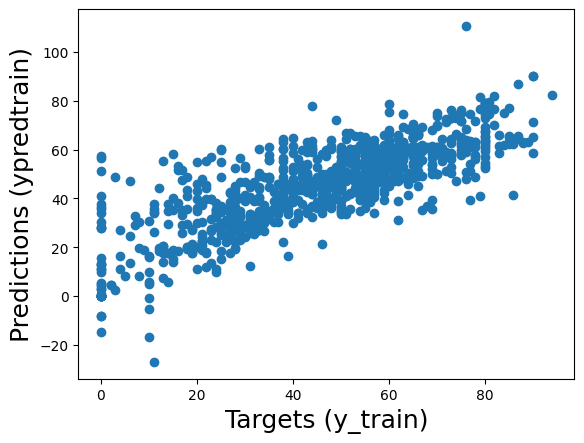

In [13]:
# The simplest way to compare the targets (y_train) and the predictions (y_hat) is to plot them on a scatter plot
# The closer the points to the 45-degree line, the better the prediction
plt.scatter(y_train, ypredtrain)
# Let's also name the axes
plt.xlabel('Targets (y_train)',size=18)
plt.ylabel('Predictions (ypredtrain)',size=18)
# Sometimes the plot will have different scales of the x-axis and the y-axis
# This is an issue as we won't be able to interpret the '45-degree line'
# We want the x-axis and the y-axis to be the same
plt.show()

### Comparação dos dados preditivos e a variável target no conjunto de dados para teste

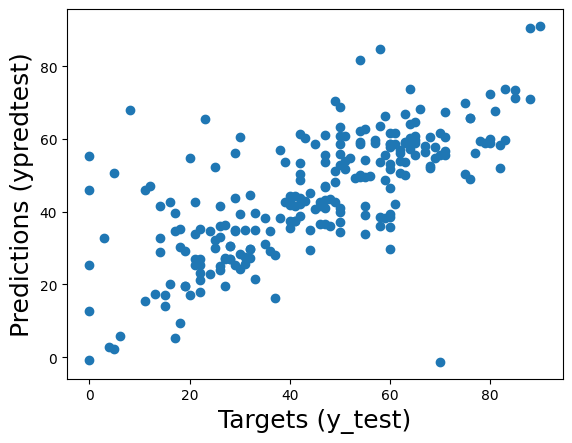

In [14]:
# The simplest way to compare the targets (y_train) and the predictions (y_hat) is to plot them on a scatter plot
# The closer the points to the 45-degree line, the better the prediction
plt.scatter(y_test, ypredtest)
# Let's also name the axes
plt.xlabel('Targets (y_test)',size=18)
plt.ylabel('Predictions (ypredtest)',size=18)
# Sometimes the plot will have different scales of the x-axis and the y-axis
# This is an issue as we won't be able to interpret the '45-degree line'
# We want the x-axis and the y-axis to be the same
plt.show()

In [15]:
print("Model slope:    ", model.coef_[0])
print("Model intercept:", model.intercept_)

Model slope:     -0.0037591678742626786
Model intercept: 79.74880620528224


In [16]:
print("Linear Regression Model Training Score:",
      model.score(x_train, y_train))

print("Linear Regression Model Testing Score:",
      model.score(x_test, y_test))


Linear Regression Model Training Score: 0.6360166716549978
Linear Regression Model Testing Score: 0.49025017803079096


### MAE

In [17]:
mae = mean_absolute_error(y_test, ypredtest)
print("MAE:", mae)


MAE: 10.48268107331889


MSE (Mean Squared Error)

Cross-validation (VERY important)


In [18]:

scores = cross_val_score(model, x_train, y_train, cv=12, scoring='r2')


print("Cross-validation scores:", scores)
print("Average CV score:", scores.mean())


Cross-validation scores: [0.43516317 0.37099031 0.42312484 0.40671632 0.45891365 0.42702258
 0.28379432 0.53381635 0.37618531 0.40463715 0.57534899 0.64085086]
Average CV score: 0.4447136537427164
